# EDA — Home Credit Default Risk: `credit_card_balance.csv`

## Purpose of this notebook

This is the last of the five tables: monthly snapshots of each client's
previous **revolving credit card** balances (`MONTHS_BALANCE` = how many
months before the current application each snapshot was taken).

Two things make this table distinct from `installments_payments.csv`:

- It's revolving credit, not installment loans — utilization (balance vs.
  credit limit) is a meaningful concept here in a way it isn't for a fixed
  installment loan.
- `SK_DPD` gives days-past-due **per month**, directly comparable to the
  lateness signal that turned out to be the strongest one found so far.

1. Load the table, check shape/types
2. One-to-many relationship with `SK_ID_CURR` (explicit merge check)
3. Missing values
4. Utilization ratio (`AMT_BALANCE` / `AMT_CREDIT_LIMIT_ACTUAL`)
5. `SK_DPD` — days past due, monthly
6. `NAME_CONTRACT_STATUS`
7. Early signal check: aggregate per client, merge with target, dose-response check


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")

cc = pd.read_csv("../data/raw/home_credit/credit_card_balance.csv")
print(f"Shape: {cc.shape[0]:,} rows x {cc.shape[1]} columns")
cc.head()

Shape: 3,840,312 rows x 23 columns


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,AMT_PAYMENT_CURRENT,AMT_PAYMENT_TOTAL_CURRENT,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,1800.0,1800.0,0.000,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,2250.0,2250.0,60175.080,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,2250.0,2250.0,26926.425,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,11925.0,11925.0,224949.285,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,27000.0,27000.0,443044.395,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


## 1. Data types and general shape

In [11]:
cc.info(verbose=False)
print()
print(cc.dtypes.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3840312 entries, 0 to 3840311
Columns: 23 entries, SK_ID_PREV to SK_DPD_DEF
dtypes: float64(15), int64(7), object(1)
memory usage: 673.9+ MB

float64    15
int64       7
object      1
Name: count, dtype: int64


## 2. One-to-many relationship with `SK_ID_CURR`

Explicit merge check against `application_train`, same pattern used since
the `previous_application.csv` bug fix.

In [12]:
app_train = pd.read_csv("../data/raw/home_credit/application_train.csv", usecols=["SK_ID_CURR", "TARGET"])
n_total_clients = app_train["SK_ID_CURR"].nunique()

clients_in_train_with_cc = app_train["SK_ID_CURR"].isin(cc["SK_ID_CURR"]).sum()
n_clients_with_no_cc = n_total_clients - clients_in_train_with_cc

print(f"Total credit_card_balance rows: {len(cc):,}")
print(f"application_train clients WITH at least one credit card record: {clients_in_train_with_cc:,}")
print(f"application_train clients with NO credit card record at all: {n_clients_with_no_cc:,} "
      f"({n_clients_with_no_cc / n_total_clients:.1%})")

records_per_client = cc.groupby("SK_ID_CURR").size()
print()
print("Distribution of monthly records per client (clients WITH at least 1):")
print(records_per_client.describe())

Total credit_card_balance rows: 3,840,312
application_train clients WITH at least one credit card record: 86,905
application_train clients with NO credit card record at all: 220,606 (71.7%)

Distribution of monthly records per client (clients WITH at least 1):
count    103558.000000
mean         37.083683
std          33.483627
min           1.000000
25%          10.000000
50%          22.000000
75%          75.000000
max         192.000000
dtype: float64


## 3. Missing values

Note: this table is expected to cover a much smaller share of clients than
the others — not everyone who applies for a Home Credit loan has ever had
a Home Credit credit card.

In [13]:
missing = cc.isna().sum()
missing_pct = (missing / len(cc) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print(missing_pct)

AMT_PAYMENT_CURRENT           19.998063
AMT_DRAWINGS_ATM_CURRENT      19.524872
CNT_DRAWINGS_POS_CURRENT      19.524872
AMT_DRAWINGS_OTHER_CURRENT    19.524872
AMT_DRAWINGS_POS_CURRENT      19.524872
CNT_DRAWINGS_OTHER_CURRENT    19.524872
CNT_DRAWINGS_ATM_CURRENT      19.524872
CNT_INSTALMENT_MATURE_CUM      7.948208
AMT_INST_MIN_REGULARITY        7.948208
dtype: float64


## 4. Utilization ratio

`AMT_BALANCE / AMT_CREDIT_LIMIT_ACTUAL` — how much of the available credit
limit is being used in a given month. Clipped to a sane range since ratios
can occasionally exceed 1.0 (over-limit) or be undefined when the limit is 0.

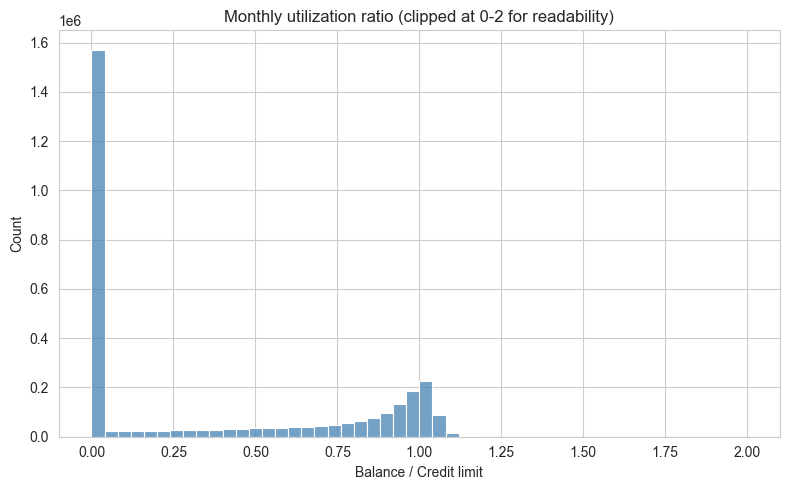

count    3.086489e+06
mean     3.746669e-01
std      4.307236e-01
min     -1.800000e+00
25%      0.000000e+00
50%      1.134400e-02
75%      8.691224e-01
max      1.177751e+01
Name: UTILIZATION, dtype: float64


In [14]:
cc["UTILIZATION"] = np.where(
    cc["AMT_CREDIT_LIMIT_ACTUAL"] > 0,
    cc["AMT_BALANCE"] / cc["AMT_CREDIT_LIMIT_ACTUAL"],
    np.nan
)

plt.figure(figsize=(8, 5))
sns.histplot(cc["UTILIZATION"].dropna().clip(0, 2), bins=50, color="steelblue")
plt.title("Monthly utilization ratio (clipped at 0-2 for readability)")
plt.xlabel("Balance / Credit limit")
plt.tight_layout()
plt.show()

print(cc["UTILIZATION"].describe())

## 5. `SK_DPD` — monthly days past due

Same kind of variable that produced the strongest signal in
`installments_payments.csv`. Checking both the raw distribution and, given
the lesson learned there, a binary/rate-based view since DPD > 0 is likely
a rare event per row.

Share of monthly snapshots with SK_DPD > 0: 3.99%


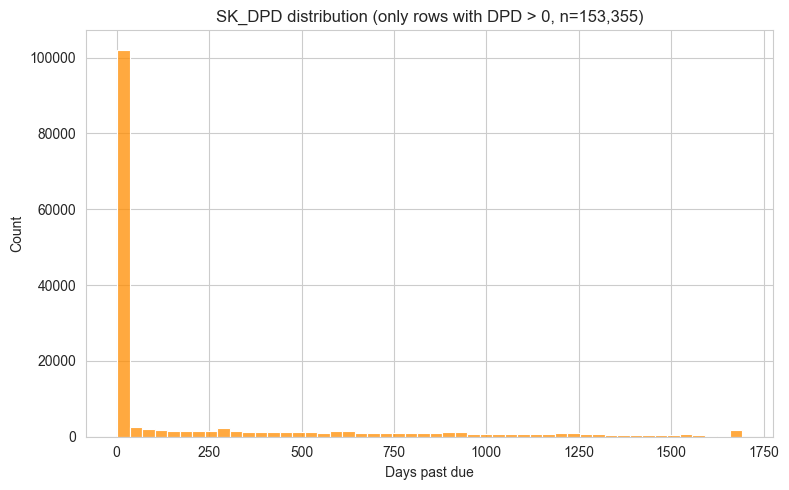

In [15]:
pct_rows_with_dpd = (cc["SK_DPD"] > 0).mean()
print(f"Share of monthly snapshots with SK_DPD > 0: {pct_rows_with_dpd:.2%}")

dpd_nonzero = cc.loc[cc["SK_DPD"] > 0, "SK_DPD"]
plt.figure(figsize=(8, 5))
sns.histplot(dpd_nonzero.clip(upper=dpd_nonzero.quantile(0.99)), bins=50, color="darkorange")
plt.title(f"SK_DPD distribution (only rows with DPD > 0, n={len(dpd_nonzero):,})")
plt.xlabel("Days past due")
plt.tight_layout()
plt.show()

## 6. `NAME_CONTRACT_STATUS`

In [16]:
status_counts = cc["NAME_CONTRACT_STATUS"].value_counts()
print(status_counts)
print()
print((status_counts / len(cc) * 100).round(2))

NAME_CONTRACT_STATUS
Active           3698436
Completed         128918
Signed             11058
Demand              1365
Sent proposal        513
Refused               17
Approved               5
Name: count, dtype: int64

NAME_CONTRACT_STATUS
Active           96.31
Completed         3.36
Signed            0.29
Demand            0.04
Sent proposal     0.01
Refused           0.00
Approved          0.00
Name: count, dtype: float64


## 7. Early signal check: aggregate per client, merge with target

Following the same successful pattern from `installments_payments.csv`:
build a dose-response check (not just ever/never), since that's what
revealed the strongest signal in the whole dataset so far.

In [17]:
client_cc_behavior = cc.groupby("SK_ID_CURR").apply(
    lambda g: pd.Series({
        "CC_AVG_UTILIZATION": g["UTILIZATION"].mean(),
        "CC_MAX_UTILIZATION": g["UTILIZATION"].max(),
        "CC_PCT_MONTHS_WITH_DPD": (g["SK_DPD"] > 0).mean(),
        "CC_MAX_DPD": g["SK_DPD"].max(),
        "CC_EVER_DPD": int((g["SK_DPD"] > 0).any()),
    }),
    include_groups=False
).reset_index()

merged = app_train.merge(client_cc_behavior, on="SK_ID_CURR", how="left")

print("Default rate by CC_EVER_DPD (0 = never had a DPD>0 month on a credit card, 1 = at least once):")
print(merged.groupby("CC_EVER_DPD")["TARGET"].agg(["mean", "count"]))

Default rate by CC_EVER_DPD (0 = never had a DPD>0 month on a credit card, 1 = at least once):
                 mean  count
CC_EVER_DPD                 
0.0          0.087855  69023
1.0          0.082206  17882


Default rate by average utilization quintile:
                        mean  count
UTILIZATION_BUCKET                 
(-0.0858, 0.0]      0.054050  26605
(0.0, 0.115]        0.056082   7810
(0.115, 0.382]      0.071424  17207
(0.382, 0.671]      0.098158  17207
(0.671, 2.0]        0.153252  17207


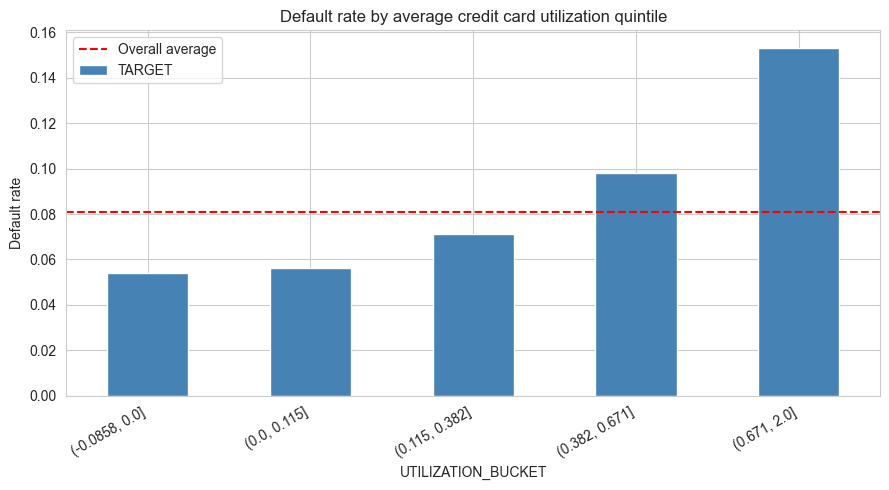

In [18]:
merged_valid = merged.dropna(subset=["CC_AVG_UTILIZATION"]).copy()
merged_valid["UTILIZATION_BUCKET"] = pd.qcut(
    merged_valid["CC_AVG_UTILIZATION"].clip(upper=2), q=5, duplicates="drop"
)

print("Default rate by average utilization quintile:")
print(merged_valid.groupby("UTILIZATION_BUCKET", observed=True)["TARGET"].agg(["mean", "count"]))

plt.figure(figsize=(9, 5))
rate_by_bucket = merged_valid.groupby("UTILIZATION_BUCKET", observed=True)["TARGET"].mean()
rate_by_bucket.plot(kind="bar", color="steelblue")
plt.axhline(merged["TARGET"].mean(), color="red", linestyle="--", label="Overall average")
plt.title("Default rate by average credit card utilization quintile")
plt.ylabel("Default rate")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Is the CC_EVER_DPD difference real, or just noise?

The default rates for `CC_EVER_DPD` (8.79% vs. 8.22%) point in the
counterintuitive direction, but the gap is small. Rather than describe it
as "probably not meaningful" without checking, run a proper two-proportion
z-test — the same discipline already applied to the baseline vs. challenger
comparison in v1.

In [19]:
from statsmodels.stats.proportion import proportions_ztest

# Group 0: never had DPD>0 on a credit card | Group 1: had it at least once
group0 = merged[merged["CC_EVER_DPD"] == 0]["TARGET"]
group1 = merged[merged["CC_EVER_DPD"] == 1]["TARGET"]

count = [group1.sum(), group0.sum()]        # defaults in each group
nobs = [len(group1), len(group0)]           # total clients in each group

z_stat, p_value = proportions_ztest(count, nobs)

print(f"Group sizes: EVER_DPD=1 -> n={nobs[0]:,}, EVER_DPD=0 -> n={nobs[1]:,}")
print(f"Default rate: EVER_DPD=1 -> {count[0]/nobs[0]:.4f}, EVER_DPD=0 -> {count[1]/nobs[1]:.4f}")
print(f"z-statistic: {z_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Statistically significant at 5%? {'YES' if p_value < 0.05 else 'NO'}")

Group sizes: EVER_DPD=1 -> n=17,882, EVER_DPD=0 -> n=69,023
Default rate: EVER_DPD=1 -> 0.0822, EVER_DPD=0 -> 0.0879
z-statistic: -2.3926
p-value: 0.0167
Statistically significant at 5%? YES


## 9. Summary and next steps

- Only 28.3% of clients (86,905 of 307,511) have any credit card balance history — the lowest coverage of any table explored.
- Clients with history have a median of 22 monthly records, mean 37.
- Several drawing-related columns are missing ~19.5% of the time — likely months with no drawing activity recorded as NaN rather than 0; should be imputed as 0 during feature engineering, not dropped.
- **Strongest dose-response signal of the entire v2 exploration**: average utilization quintile shows default rate rising from 5.41% to 15.33% — a 183% relative increase, stronger than any other table.
- `CC_EVER_DPD` shows a small but **statistically significant** counterintuitive effect (8.79% vs. 8.22%, p=0.0167, two-proportion z-test) — real, not noise, but the effect size is small and the direction is unintuitive. Likely confounded with overall card engagement/usage intensity, which `CC_AVG_UTILIZATION` already captures more directly and more strongly. Recommendation: prioritize the continuous utilization feature over this flag; include the flag only as a minor secondary feature if at all.

**This closes the exploratory phase across all 5 tables.** Ranking of the strongest signals found:
1. `CC_AVG_UTILIZATION` (credit_card_balance.csv) — dose-response, 183% relative increase
2. `PCT_INSTALLMENTS_LATE` (installments_payments.csv) — dose-response, 66% relative increase
3. `EVER_OVERDUE` (bureau.csv) — binary, ~99% relative increase (2x)
4. `EVER_REFUSED` (previous_application.csv) — binary, 48% relative increase
5. `HAS_BUREAU_HISTORY` (bureau.csv) — counterintuitive direction, no history = higher risk
6. `CC_EVER_DPD` (credit_card_balance.csv) — statistically significant but practically small and counterintuitive; low priority

**Next step:** design and implement the multi-table feature engineering pipeline (`build_features_v2.py`), translating these findings into a reusable, leakage-free feature set — same discipline as v1's `build_features.py`.